
========== Data Analysis & Visualization Program ==========
Please select an option:
1. Load Dataset
2. Explore Data
3. Perform DataFrame Operations
4. Handle Missing Data
5. Generate Descriptive Statistics
6. Data Visualization
7. Save Visualization
8. Exit
Loaded data Successfully!


Enter your choice:  6



--- Data Visualization Menu ---
1. Line Plot (Trend)
2. Bar Chart (Group By)
3. Histogram
4. Box Plot
5. Scatter Plot
6. Correlation Heatmap
7. Pie Chart
8. Multiple Numeric Plots
9. Time Series Plot
0. Exit and Show Summary

Numeric columns: ['Order ID', 'Quantity Ordered', 'Price Each', 'Sales']
Categorical columns: ['Product', 'Purchase Address', 'City']
Date columns: None


C:\Users\Admin\AppData\Local\Temp\ipykernel_14220\1789593518.py:390: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()


Enter your choice:  7
Enter categorical column:  City


Visualization saved at: pie_City\Figure(600x600)_20260202_121825.png


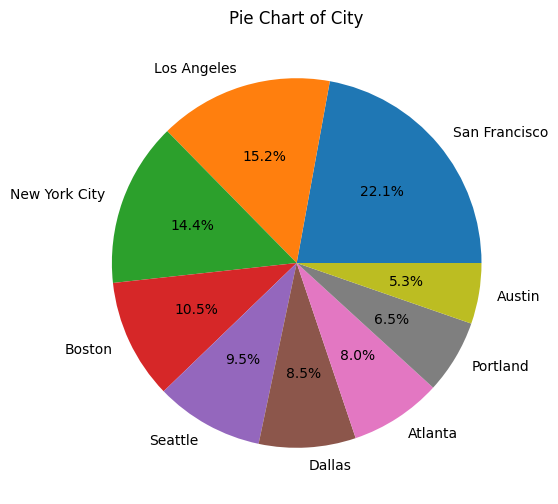


--- Data Visualization Menu ---
1. Line Plot (Trend)
2. Bar Chart (Group By)
3. Histogram
4. Box Plot
5. Scatter Plot
6. Correlation Heatmap
7. Pie Chart
8. Multiple Numeric Plots
9. Time Series Plot
0. Exit and Show Summary

Numeric columns: ['Order ID', 'Quantity Ordered', 'Price Each', 'Sales']
Categorical columns: ['Product', 'Purchase Address', 'City']
Date columns: None


Enter your choice:  0



--- Visualization Summary ---
Total plots: 1
- Pie Chart

========== Data Analysis & Visualization Program ==========
Please select an option:
1. Load Dataset
2. Explore Data
3. Perform DataFrame Operations
4. Handle Missing Data
5. Generate Descriptive Statistics
6. Data Visualization
7. Save Visualization
8. Exit
Loaded data Successfully!
SalesDataAnalyzer object deleted.


Enter your choice:  7
Enter plot name to save:  pie


Visualization saved at: saved_plots\pie_20260202_121844.png

========== Data Analysis & Visualization Program ==========
Please select an option:
1. Load Dataset
2. Explore Data
3. Perform DataFrame Operations
4. Handle Missing Data
5. Generate Descriptive Statistics
6. Data Visualization
7. Save Visualization
8. Exit
Loaded data Successfully!
SalesDataAnalyzer object deleted.


In [ ]:
import pandas as pd
from datetime import datetime, date, time, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os


# this Class contain all Functionality...
class SalesDataAnalyzer:
    def __init__(self, file_path=None):
        self.data = None  # Datafram to store sales data..
        if file_path:
            self.load_data(file_path) # load_data fuction use
        self.data['Order ID'] = self.data['Order ID'].astype('Int64')
        self.data['Quantity Ordered'] = self.data['Quantity Ordered'].astype('Int64')
        self.data["Sales"] = (self.data["Quantity Ordered"] * self.data["Price Each"])
        self.data["City"] = (self.data["Purchase Address"].str.split(",").str[1].str.strip())


    # Destructor
    def __del__(self):
        print("SalesDataAnalyzer object deleted.")

    def load_data(self,file_path):
        try:
            self.data = pd.read_csv(file_path) #load sales data
            print("Loaded data Successfully!")
        except Exception as e:
            print("Ocuure error while Loading file : ",e)

    def explore_data(self):
        if self.data is None:
            print("NO data avalible..")
            return

        while True:
            print("\n===== Explore Data Menu =====")
            print("1. Display first 5 rows")
            print("2. Display last 5 rows")
            print("3. Display dataset shape")
            print("4. Display column names")
            print("5. Display data types")
            print("6. Display basic info")
            print("7. Display Random 10 rows")
            print("8. Exit")

            op = int(input("Choose an Option : "))
            match op:
                case 1: 
                    print("\n--- First 5 Rows ---\n")
                    print(self.data.head())
                case 2:
                    print("\n--- Last 5 Rows ---\n")
                    print(self.data.tail())
                case 3:
                    print("\n--- Display Shape of the data ---\n")
                    print("(Row,Column) of dataset : ",self.data.shape)  # (total Row , total column)
                case 4:
                    print("\n--- Display Column name  ---\n")         
                    print(self.data.columns)#show column name
                case 5:
                    print("\n--- Display data types ---\n")
                    print(self.data.dtypes) #show type of all column
                case 6:
                    print("\n--- Display basic info  ---\n")
                    print(self.data.info) # display first 5 and last 5 records
                case 7:
                    print("\n--- Display random 10 rows ---\n")
                    print(self.data.sample(10)) # randomly select 10 rows
                case 8:
                    print("\n --- Exit From the submenu ---\n")
                    break
                case _:
                    print("\n--- Choose correct.. ---\n")

    def clean_data(self):
        if self.data is None:
            print("NO data avalible..")
            return
            
        while True:
            print(self.data.dtypes)
            print("\n===== Clear data =====")
            print("\n Total NUmber of row in dataset : ",len(self.data)) #total no of rows
            print("\n1.Checking missing values(Boolean)")
            print("2.Check total misiing value.")
            print("3.Check unique items.")
            print("4.Handle missing value.")
            print("5.Check duplicate items ")
            print("0.Exit from Sub menu")
            

            choice = int(input("choose an option :  "))
            
            
            match choice:
                case 1:
                    print("\n --- Finding missing values(boolean) ---\n ")
                    print(self.data.isna()) #represent in bollean form of missing data
                case 2:
                    print("\n--- check for missing values ---\n")
                    print(self.data.isnull().sum())# give column wise null value
                case 3:
                    print("\n --- Dispaly Unique items ---")
                    print(self.data.nunique()) #number of unique users and items 
                case 4:
                    print("---- Handle missing values ----")
                    print("1.Filling value in column")
                    print("2.Drop null value column")
                    op = int(input("Enter missing value option"))
                    match op:
                        case 1:
                              #print("\nHandle Price Each colum vale with median")
                            self.data["Price Each"] = self.data["Price Each"].fillna(self.data["Price Each"].median()) # fillvalue with median.
                             
                            #print("\nHandle quantity order value...")
                            self.data["Quantity Ordered"].fillna(0)     
                            
                              #print("\nFill product with Mode...")
                            self.data['Product'] = self.data['Product'].fillna(self.data['Product'].mode()[0]) #fill value with mode
                           
                            self.data['Quantity Ordered'] = self.data['Quantity Ordered'].fillna(self.data['Quantity Ordered'].median())
                            
                            #print("\nFill Purchase Address with custom message..")
                            self.data['Purchase Address'] = self.data['Purchase Address'].fillna('Address Not Available') #fill with custom message
                            self.data['Order Date'] = pd.to_datetime(self.data['Order Date'])  #convert date to date formanate
                            self.data["Order Date"]  = self.data["Order Date"].fillna(datetime.now()) # fill with current date.
                            self.data["Order ID"] = self.data["Order ID"].fillna(0)   # null order id fil with 0
                            print("\nMissing values after cleaning:") #print after handling missing data
                            print(self.data.isna().sum())
                           
                        case 2:
                            print("\n Drop Null value column")
                            self.data.dropna(inplace=True)
                            print("\nMissing values after cleaning:")
                            print(self.data.isnull().sum())
                case 5:
                    print("\n --- Display Dublicate value --- ")
                    print(self.data.duplicated().sum()) # total duplicate data
                case 6:
                    print("Exit...")
                    break
                case _:
                    print("Invlide Choice..")
                
 
    def Stastical_data(self):
        while True:
            print("\n--- Generate Descriptive Statistics ---")
            print("1. Summary statistics (mean, median, std, min, max)")
            print("2. Column-wise statistics")
            print("3. Correlation matrix")
            print("4. Value counts for categorical data")
            print("5. Percentiles / Quartiles")
            print("6. Skewness & Kurtosis")
            print("7. Numeric vs Categorical summary")
            print("0. Back to main menu")
        
            choice = int(input("Enter your choice: "))
        
            match choice:
        
                case 1:
                    print("\nSummary Statistics:")
                    print(self.data.describe())
        
                case 2:
                    print("\nColumn-wise Statistics:")
                    for col in self.data.select_dtypes(include='number').columns:
                        print(f"\nColumn: {col}")
                        print("Mean:", self.data[col].mean())
                        print("Median:", self.data[col].median())
                        print("Std Dev:", self.data[col].std())
                        print("Min:", self.data[col].min())
                        print("Max:", self.data[col].max())
        
                case 3:
                    print("\nCorrelation Matrix:")
                    print(self.data.select_dtypes(include='number').corr())
        
                case 4:
                    print("\nValue Counts (Categorical Columns):")
                    for col in self.data.select_dtypes(include='object').columns:
                        print(f"\n{col}:")
                        print(self.data[col].value_counts())
        
                case 5:
                    print("\nPercentiles / Quartiles:")
                    print(self.data.select_dtypes(include='number').quantile([0.25, 0.5, 0.75]))
        
                case 6:
                    print("\nSkewness & Kurtosis:")
                    for col in self.data.select_dtypes(include='number').columns:
                        print(f"\n{col}")
                        print("Skewness:", self.data[col].skew())
                        print("Kurtosis:", self.data[col].kurt())
        
                case 7:
                    print("\nNumeric Columns Summary:")
                    print(self.data.select_dtypes(include='number').describe())
        
                    print("\nCategorical Columns Summary:")
                    print(self.data.select_dtypes(include='object').describe())
        
                case 0:
                    print("Returning to main menu...")
                    break
        
                case _:
                    print("Invalid choice. Please try again.")
#done
# 3 . data frame operation 
    def dataframe_operations(self):

        if self.data is None:
            print("No dataset loaded.")
            return
    
        import pandas as pd
    
        df = self.data
    
        while True:
            print("\n--- DataFrame Operations Menu ---")
            print("1. View Columns")
            print("2. Select Columns")
            print("3. Filter Rows")
            print("4. Sort Data")
            print("5. Add New Column")
            print("6. Rename Column")
            print("7. Drop Column")
            print("8. Group By Operation")
            print("9. Show Unique Values")
            print("10. Change Data Type")
            print("0. Back to Main Menu")
    
            try:
                choice = int(input("Enter your choice: "))
            except ValueError:
                print("Invalid input.")
                continue
    
            match choice:
    
                case 1:  # View columns
                    print("Columns:")
                    for col in df.columns:
                        print("-", col)
    
                case 2:  # Select columns
                    cols = input("Enter column names (comma separated): ").split(",")
                    cols = [c.strip() for c in cols if c.strip() in df.columns]
    
                    if cols:
                        print(df[cols].head())
                    else:
                        print("No valid columns selected.")
    
                case 3:  # Filter rows
                    col = input("Enter column name: ")
    
                    if col not in df.columns:
                        print("Invalid column.")
                        continue
    
                    value = input("Enter value to filter by: ")
                    result = df[df[col].astype(str) == value]
    
                    print(result.head())
                    print("Rows matched:", len(result))
    
                case 4:  # Sort data
                    col = input("Enter column to sort by: ")
    
                    if col not in df.columns:
                        print("Invalid column.")
                        continue
    
                    order = input("Ascending? (yes/no): ").lower()
                    ascending = True if order == "yes" else False
    
                    print(df.sort_values(by=col, ascending=ascending).head())
    
                case 5:  # Add new column
                    new_col = input("Enter new column name: ")
                    base_col = input("Enter existing numeric column: ")
    
                    if base_col in df.columns:
                        try:
                            factor = float(input("Enter multiplier value: "))
                            df[new_col] = df[base_col] * factor
                            print(f"Column '{new_col}' added.")
                        except ValueError:
                            print("Invalid multiplier.")
                    else:
                        print("Invalid column.")
    
                case 6:  # Rename column
                    old = input("Enter old column name: ")
                    new = input("Enter new column name: ")
    
                    if old in df.columns:
                        df.rename(columns={old: new}, inplace=True)
                        print("Column renamed.")
                    else:
                        print("Invalid column.")
    
                case 7:  # Drop column
                    col = input("Enter column to drop: ")
    
                    if col in df.columns:
                        df.drop(columns=[col], inplace=True)
                        print("Column dropped.")
                    else:
                        print("Invalid column.")
    
                case 8:  # Group by operation
                    group_col = input("Enter group by column: ")
                    agg_col = input("Enter numeric column: ")
                    agg_func = input("Aggregation (sum/mean/max/min/count): ").lower()
    
                    if group_col in df.columns and agg_col in df.columns:
                        if agg_func in ["sum", "mean", "max", "min", "count"]:
                            result = df.groupby(group_col)[agg_col].agg(agg_func)
                            print(result)
                        else:
                            print("Invalid aggregation function.")
                    else:
                        print("Invalid columns.")
    
                case 9:  # Unique values
                    col = input("Enter column name: ")
    
                    if col in df.columns:
                        print("Unique values:")
                        print(df[col].unique())
                    else:
                        print("Invalid column.")
    
                case 10:  # Change data type
                    col = input("Enter column name: ")
                    dtype = input("Enter new type (int, float, str): ")
    
                    if col not in df.columns:
                        print("Invalid column.")
                        continue
    
                    try:
                        match dtype:
                            case "int":
                                df[col] = df[col].astype(int)
                            case "float":
                                df[col] = df[col].astype(float)
                            case "str":
                                df[col] = df[col].astype(str)
                            case _:
                                print("Unsupported data type.")
                                continue
    
                        print("Data type changed successfully.")
                    except ValueError:
                        print("Data type conversion failed.")
    
                case 0:
                    print("Returning to main menu.")
                    break
    
                case _:
                    print("Invalid choice.")



#graph nathi batavta

    def data_visualization(self):  # select numeric as a sels and categori = city for visulization
    
        if self.data is None:
            print("No data loaded.")
            return
    
        df = self.data.copy()
        
    
        date_cols = [c for c in df.columns if "date" in c.lower() or "time" in c.lower()]
        for c in date_cols:
            df[c] = pd.to_datetime(df[c], errors="coerce")
    
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
    
        visualizations_done = []
    
        # MENU LOOP
        while True:
            print("\n--- Data Visualization Menu ---")
            print("1. Line Plot (Trend)")
            print("2. Bar Chart (Group By)")
            print("3. Histogram")
            print("4. Box Plot")
            print("5. Scatter Plot")
            print("6. Correlation Heatmap")
            print("7. Pie Chart")
            print("8. Multiple Numeric Plots")
            print("9. Time Series Plot")
            print("0. Exit and Show Summary")
    
            print("\nNumeric columns:", numeric_cols)
            print("Categorical columns:", categorical_cols)
            print("Date columns:", date_cols if date_cols else "None")
    
            try:
                choice = int(input("Enter your choice: "))
            except ValueError:
                print("Invalid input.")
                continue
    
            # 1. LINE PLOT
            if choice == 1:
                x = input("Enter X-axis column: ") 
                y = input("Enter Y-axis numeric column: ")
    
                if x in df.columns and y in numeric_cols:
                    fig = plt.figure(figsize=(8, 4))
                    plt.plot(df[x], df[y])
                    plt.xlabel(x)
                    plt.ylabel(y)
                    plt.title(f"{y} vs {x}")
    
                    self.save_visualization(fig, f"line_{y}_vs_{x}")
                    plt.show()
    
                    visualizations_done.append("Line Plot")
                else:
                    print("Invalid columns.")
    
            # 2. BAR CHART
            elif choice == 2:
                cat = input("Enter categorical column: ")
                num = input("Enter numeric column: ") # sales select column
    
                if cat in categorical_cols and num in numeric_cols:
                    fig = plt.figure(figsize=(8, 4))
                    df.groupby(cat)[num].sum().plot(kind="bar")
                    plt.xlabel(cat)
                    plt.ylabel(num)
                    plt.title(f"{num} grouped by {cat}")
    
                    self.save_visualization(fig, f"bar_{num}_by_{cat}")
                    plt.show()
    
                    visualizations_done.append("Bar Chart")
                else:
                    print("Invalid columns.")
    
            # 3. HISTOGRAM
            elif choice == 3:
                col = input("Enter numeric column: ")
    
                if col in numeric_cols:
                    fig = plt.figure(figsize=(6, 4))
                    plt.hist(df[col], bins=30)
                    plt.title(f"Histogram of {col}")
    
                    self.save_visualization(fig, f"hist_{col}")
                    plt.show()
    
                    visualizations_done.append("Histogram")
                else:
                    print("Invalid column.")
    
            # 4. BOX PLOT
            elif choice == 4:
                col = input("Enter numeric column: ")
    
                if col in numeric_cols:
                    fig = plt.figure(figsize=(4, 4))
                    sns.boxplot(y=df[col])
                    plt.title(f"Box Plot of {col}")
    
                    self.save_visualization(fig, f"box_{col}")
                    plt.show()
    
                    visualizations_done.append("Box Plot")
                else:
                    print("Invalid column.")
    
            # 5. SCATTER PLOT
            elif choice == 5:
                x = input("Enter numeric X column: ")
                y = input("Enter numeric Y column: ")
    
                if x in numeric_cols and y in numeric_cols:
                    fig = plt.figure(figsize=(6, 4))
                    plt.scatter(df[x], df[y])
                    plt.xlabel(x)
                    plt.ylabel(y)
                    plt.title(f"{x} vs {y}")
    
                    self.save_visualization(fig, f"scatter_{x}_vs_{y}")
                    plt.show()
    
                    visualizations_done.append("Scatter Plot")
                else:
                    print("Invalid columns.")
    
            # 6. HEATMAP
            elif choice == 6:
                fig = plt.figure(figsize=(6, 5))
                sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
                plt.title("Correlation Heatmap")
    
                self.save_visualization(fig, "correlation_heatmap")
                plt.show()
    
                visualizations_done.append("Heatmap")
    
            # 7. PIE CHART
            elif choice == 7:
                col = input("Enter categorical column: ")
    
                if col in categorical_cols:
                    fig = plt.figure(figsize=(6, 6))
                    df[col].value_counts().plot(kind="pie", autopct="%1.1f%%")
                    plt.ylabel("")
                    plt.title(f"Pie Chart of {col}")
    
                    self.save_visualization(fig, f"pie_{col}")
                    plt.show()
    
                    visualizations_done.append("Pie Chart")
                else:
                    print("Invalid column.")
    
            # 8. MULTIPLE NUMERIC PLOTS
            elif choice == 8:
                fig = plt.figure(figsize=(10, 8))
                df[numeric_cols].plot(subplots=True)
    
                self.save_visualization(fig, "multiple_numeric_plots")
                plt.show()
    
                visualizations_done.append("Multiple Plots")
    
            # 9. TIME SERIES
            elif choice == 9:
                if not date_cols:
                    print("No date column found.")
                else:
                    date = date_cols[0]
                    num = input("Enter numeric column: ")
    
                    if num in numeric_cols:
                        df_sorted = df.sort_values(date)
    
                        fig = plt.figure(figsize=(8, 4))
                        plt.plot(df_sorted[date], df_sorted[num])
                        plt.xlabel(date)
                        plt.ylabel(num)
                        plt.title(f"{num} Over Time")
    
                        self.save_visualization(fig, f"time_{num}")
                        plt.show()
    
                        visualizations_done.append("Time Series")
                    else:
                        print("Invalid column.")
    
            # EXIT
            elif choice == 0:
                print("\n--- Visualization Summary ---")
                print("Total plots:", len(visualizations_done))
                for v in set(visualizations_done):
                    print("-", v)
                break
    
            else:
                print("Invalid choice.")
    


    #save visualization for save the chart
    def save_visualization(self, plot_name, folder_name="saved_plots", file_format="png"):
        if not os.path.exists(folder_name):  #create folder if not created
            os.makedirs(folder_name)
    
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        file_name = f"{plot_name}_{timestamp}.{file_format}"
        file_path = os.path.join(folder_name, file_name) # file path
    
        plt.savefig(file_path, dpi=300, bbox_inches="tight")
        print(f"Visualization saved at: {file_path}")


#main menu 
def main_menu():

    while True:
        print("\n========== Data Analysis & Visualization Program ==========")
        print("Please select an option:")
        print("1. Load Dataset")
        print("2. Explore Data")
        print("3. Perform DataFrame Operations")
        print("4. Handle Missing Data")
        print("5. Generate Descriptive Statistics")
        print("6. Data Visualization")
        print("7. Save Visualization")
        print("8. Exit")
        print("===========================================================")
        analyzer = SalesDataAnalyzer("sales_data1.csv")

        try:
            choice = int(input("Enter your choice: "))
        except ValueError:
            print("Invalid input. Please enter a number.")
            continue
        

        match choice:
            case 1:
                analyzer.load_data("sales_data1.csv") # load the dataset

            case 2:
                analyzer.explore_data() #about data
            case 3:
                analyzer.dataframe_operations()

            case 4:
                analyzer.clean_data()

            case 5:
                analyzer.Stastical_data()

            case 6:
                analyzer.data_visualization()

            case 7:
                plot_name = input("Enter plot name to save: ")
                analyzer.save_visualization(plot_name)

            case 8:
                print("Exiting program.")
                break

            case _:
                print("Invalid choice. Please try again.")

main_menu()

